In [1]:
import importlib
import numpy as np
import os
import EEGNet_Eneriz_2 as EEG
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
samples,labels,subjects = EEG.LoadDatabase(r'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet',Channels=64)

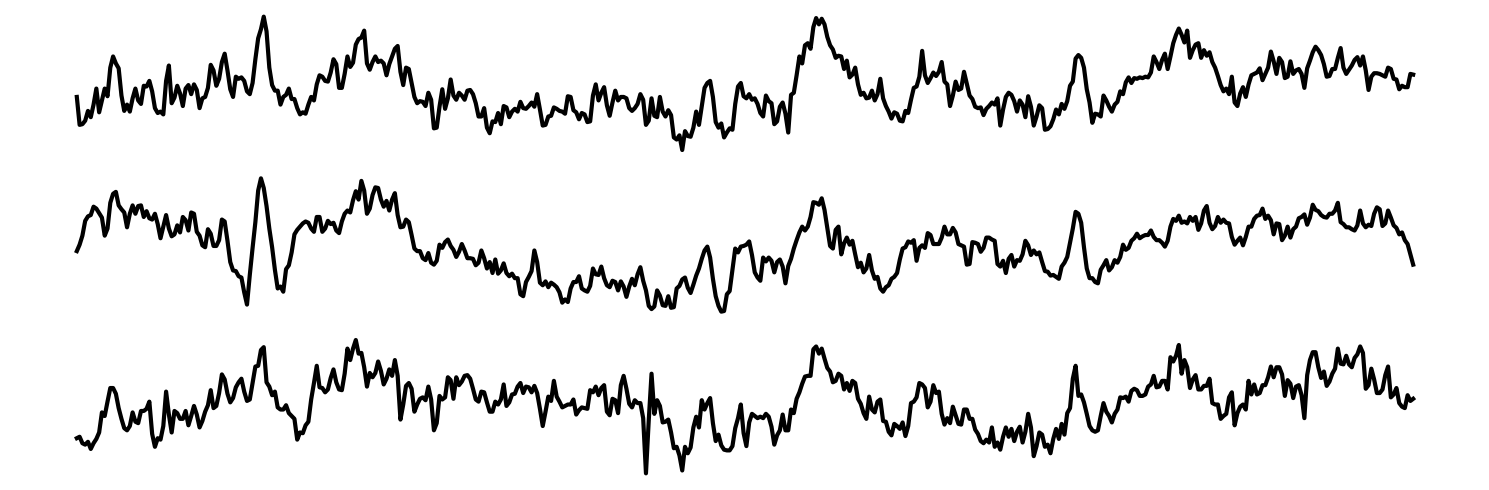

In [11]:
fig, ax = plt.subplots(3,1, figsize=(15,5), sharex=True)
fs = 160
t = np.arange(0, 1/fs * len(samples[0,0]), 1/fs)

# Plot
ax[0].plot(t, samples[0,0], color='black', linewidth=3)
ax[1].plot(t, samples[0,50], color='black', linewidth=3)
ax[2].plot(t, samples[0,25], color='black', linewidth=3)

# Eliminar bordes, ticks y etiquetas
for a in ax:
    a.set_frame_on(False)          # sin recuadro
    a.set_xticks([])               # sin ticks X
    a.set_yticks([])               # sin ticks Y
    a.set_xlabel("")               # sin etiqueta X
    a.set_ylabel("")               # sin etiqueta Y
    a.spines['top'].set_visible(False)
    a.spines['bottom'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [5]:
example = samples[0,0,:160]
transform = np.fft.rfft(example,n=480)


In [3]:
MAX_LEN = len(samples[0,0])
w_len = int(MAX_LEN/3)
w_delay = 100



In [ ]:

weights_folder = r'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\subjectSpecific\subjectSpecific1_cv4_chan64_samples160_nbClasses4_ds1\pesos_fold0.weights.h5'


model = EEG.EEGNet_Eneriz(nb_classes,ds,Channels,Samples)
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam() , 
    metrics = ['accuracy'])

#Si queremos entrenar con unos pesos iniciales concretos
if(weights_folder!=None):
    model.load_weights(weights_folder)
    print(f'Pesos cargados desde : {weights_folder}')

Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\subjectSpecific\subjectSpecific1_cv4_chan64_samples160_nbClasses4_ds1\pesos_fold0.weights.h5


c:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:

nb_classes = 4
ds = 1
Channels = 64
Samples = 241

output_folder = rf'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\moving_windowFFT'

w_delay_values = np.arange(0,60,1)

for w_delay in w_delay_values:
    print(f'w_delay {w_delay:.0f}')
    acc_matrix = np.zeros((len(np.unique(subjects)),4,len(np.unique(labels))))

    for i_subject, subject in enumerate(np.unique(subjects)):
        print(f'Sujeto específico : {subject:.0f}')
        samples_specific, labels_specific, subjects_specific = EEG.subjectSpecificData(subject,samples[:,:,w_delay: w_delay + w_len],labels,subjects)

        #TRANSFORMADA DE FOURIER DE LOS DATOS 
        samples_specific = np.fft.rfft(samples_specific,n=480)
        print(samples_specific.shape)

        samples_cv, labels_cv, subjects_cv = EEG.cvPartition(4,samples_specific,labels_specific,subjects_specific,Channels=64,Samples=Samples)

        for fold in range(4):
            #Se cargan los pesos del sujeto específico y del fold 
            weights_folder = rf'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\subjectSpecificFFT\subjectSpecific{subject:.0f}_cv4_chan64_samples{Samples:.0f}_nbClasses4_ds1\pesos_fold{fold:.0f}.weights.h5'

            model = EEG.EEGNet_Eneriz(nb_classes,ds,Channels,Samples)
            model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam() , 
                metrics = ['accuracy']) #me podría ahorrar esto de compilar el modelo cada vez, con cargar los pesos entiendo que vale
            model.load_weights(weights_folder)

            #tomar los datos de validación de ese sujeto y fold específico
            for categoria in range(len(np.unique(labels))):
                #print(f'categoria {categoria}')
                idx = np.where(labels_cv[fold,:,categoria]==1)[0]
                #print(idx)
                
                X_train = samples_cv[fold,idx]
                Y_train = labels_cv[fold,idx]
                loss, acc_matrix[i_subject,fold,categoria] = model.evaluate(X_train,Y_train,verbose=0)
                #print(f'fold : {fold:.0f} || acc : {acc_matrix[i_subject,fold,categoria]:.2f}')
    
    np.save(f'delay{w_delay:.0f}.npy',acc_matrix)




w_delay 0
Sujeto específico : 1
(84, 64, 241)
Sujeto específico : 2
(84, 64, 241)
Sujeto específico : 3
(84, 64, 241)
Sujeto específico : 4
(84, 64, 241)
Sujeto específico : 5
(84, 64, 241)
Sujeto específico : 6
(84, 64, 241)
Sujeto específico : 7
(84, 64, 241)
Sujeto específico : 8
(84, 64, 241)
Sujeto específico : 9
(84, 64, 241)
Sujeto específico : 10
(84, 64, 241)
Sujeto específico : 11
(84, 64, 241)
Sujeto específico : 12
(84, 64, 241)
Sujeto específico : 13
(84, 64, 241)
Sujeto específico : 14
(84, 64, 241)
Sujeto específico : 15
(84, 64, 241)
Sujeto específico : 16
(84, 64, 241)
Sujeto específico : 17
(84, 64, 241)
Sujeto específico : 18
(84, 64, 241)
Sujeto específico : 19
(84, 64, 241)
Sujeto específico : 20
(84, 64, 241)
Sujeto específico : 21
(84, 64, 241)
Sujeto específico : 22
(84, 64, 241)
Sujeto específico : 23
(84, 64, 241)
Sujeto específico : 24
(84, 64, 241)
Sujeto específico : 25
(84, 64, 241)
Sujeto específico : 26
(84, 64, 241)
Sujeto específico : 27
(84, 64, 241)


categoria 0 mean : 0.5723015944517794
categoria 1 mean : 0.5688095314516908
categoria 2 mean : 0.6929365152759211
categoria 3 mean : 0.566904768489656


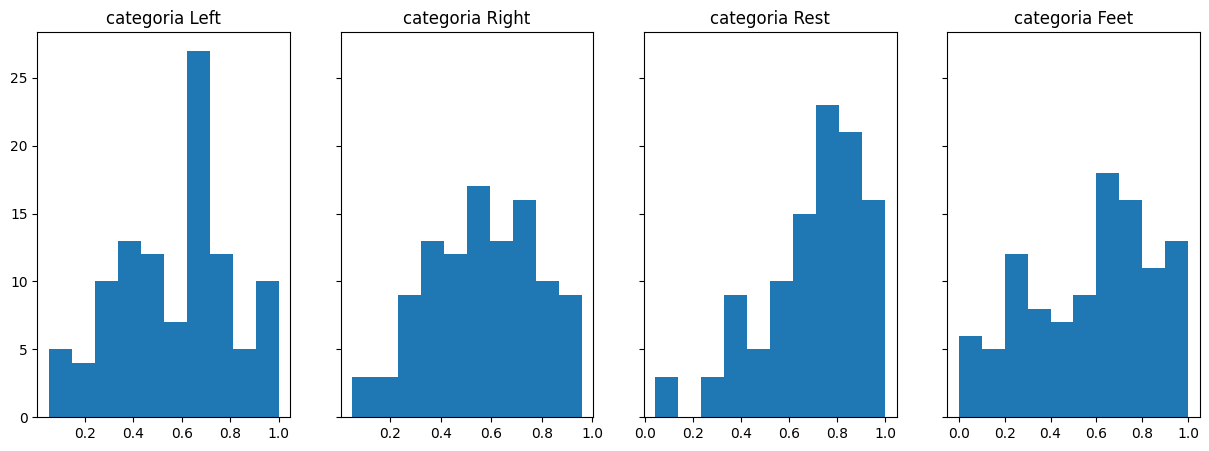

In [13]:
nombres_categorias = ['Left','Right', 'Rest', 'Feet']

acc_matrix = np.load(f'delay0.npy')
acc_matrix_meanFolds = np.mean(acc_matrix, axis=1)

fig,ax = plt.subplots(1,4,sharey=True,figsize=(15,5))

for categoria in range(4):
    ax[categoria].hist(acc_matrix_meanFolds[:,categoria])
    ax[categoria].set_title(f'categoria {nombres_categorias[categoria]}')
    print(f'categoria {categoria} mean : {np.mean(acc_matrix_meanFolds[:,categoria])}')



In [6]:
w_delay_values = np.arange(0,60,1)

acc_meanFFT = np.zeros((len(w_delay_values),4))
acc_desvFFT = np.zeros((len(w_delay_values),4))

for i_delay, w_delay in enumerate(w_delay_values):
    acc_matrix = np.load(f'delayFFT/delay{w_delay:.0f}.npy')
    for categoria in range(4):
        acc_meanFFT[i_delay,categoria] = np.mean(acc_matrix,axis=(0,1))[categoria]
        acc_desvFFT[i_delay,categoria] = np.std(acc_matrix,axis=(0,1))[categoria]
        if (i_delay==0):
            print(f'FFT categoria {categoria} {acc_meanFFT[i_delay,categoria]} +- {acc_desvFFT[i_delay,categoria]}')
            acc0_totalMean = np.mean(acc_matrix)
            acc0_totalDesv = np.std(acc_matrix)
            print(f'({acc0_totalMean}) {acc0_totalDesv}')


w_delay_values = np.arange(0,60,1)

acc_mean = np.zeros((len(w_delay_values),4))
acc_desv = np.zeros((len(w_delay_values),4))

for i_delay, w_delay in enumerate(w_delay_values):
    acc_matrix = np.load(f'delays/delay{w_delay:.0f}.npy')
    for categoria in range(4):
        acc_mean[i_delay,categoria] = np.mean(acc_matrix,axis=(0,1))[categoria]
        acc_desv[i_delay,categoria] = np.std(acc_matrix,axis=(0,1))[categoria]
        if (i_delay==0):
            print(f'Normal categoria {categoria} {acc_mean[i_delay,categoria]} +- {acc_desv[i_delay,categoria]}')
            acc0_totalMean = np.mean(acc_matrix)
            acc0_totalDesv = np.std(acc_matrix)
            print(f'({acc0_totalMean}) {acc0_totalDesv}')


FFT categoria 0 0.5723015944517794 +- 0.3078470966512749
(0.6002381024172618) 0.3116391994268271
FFT categoria 1 0.5688095314516908 +- 0.29821011148856164
(0.6002381024172618) 0.3116391994268271
FFT categoria 2 0.6929365152759211 +- 0.28640325644476516
(0.6002381024172618) 0.3116391994268271
FFT categoria 3 0.566904768489656 +- 0.3335831548763837
(0.6002381024172618) 0.3116391994268271
Normal categoria 0 0.6267460406181358 +- 0.2717696145263639
(0.6460515955729144) 0.2659022111478144
Normal categoria 1 0.6079365166879835 +- 0.27269083590533233
(0.6460515955729144) 0.2659022111478144
Normal categoria 2 0.7165873091135706 +- 0.2336335764519473
(0.6460515955729144) 0.2659022111478144
Normal categoria 3 0.6329365158719676 +- 0.2702582547677942
(0.6460515955729144) 0.2659022111478144


In [6]:
acc_matrix.shape

(105, 4, 4)

(40, 4)

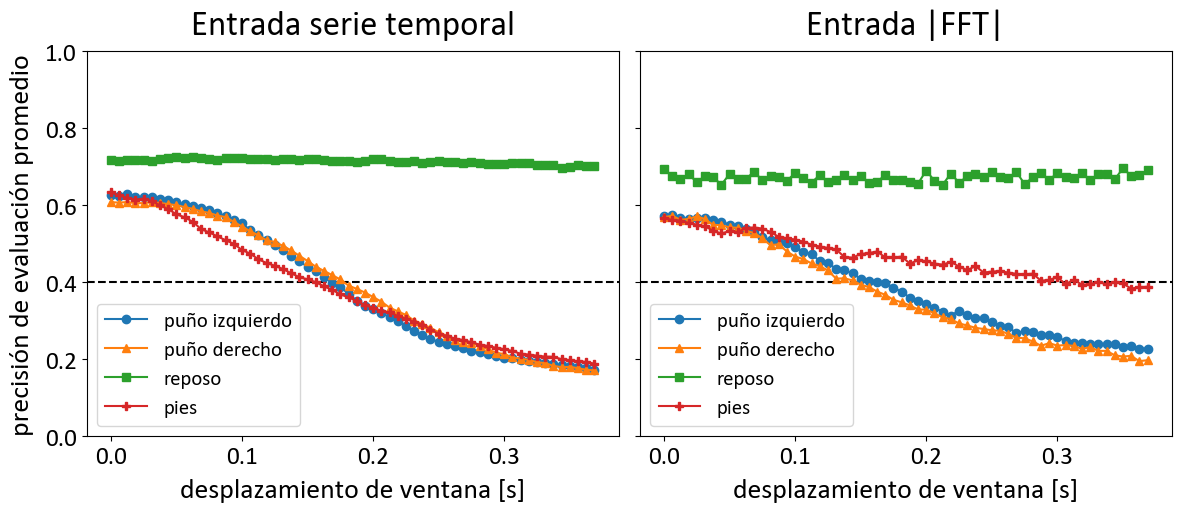

In [8]:
nombres_categorias = ['puño izquierdo','puño derecho', 'reposo', 'pies']
marker_list = ['o', '^', 's', 'P' ]


plt.rcParams['font.family'] = 'Calibri'


fig,ax = plt.subplots(1,2, figsize = (14,5), sharey=True)
plt.subplots_adjust(wspace=0.04)
ax[0].axhline(0.4, linestyle= '--', color = 'black')
for i in range(4):
    ax[0].plot(w_delay_values/160,acc_mean[:,i], label = f'{nombres_categorias[i]}', marker= marker_list[i])
    #ax[0].fill_between(w_delay_values/160, acc_mean[:,i] - acc_desv[:,i], acc_mean[:,i] + acc_desv[:,i], alpha=0.2)
ax[0].set_xlabel('desplazamiento de ventana [s]', fontsize = 20, labelpad=8)
ax[0].set_ylabel('precisión de evaluación promedio', fontsize = 20, labelpad=8)
ax[0].set_ylim([0,1])
ax[0].set_title('Entrada serie temporal', fontsize = 25, pad=12)
ax[0].legend(loc='lower left', fontsize= 15)
ax[0].tick_params(labelsize=18)

ax[1].axhline(0.4, linestyle= '--',color = 'black')
for i in range(4):
    ax[1].plot(w_delay_values/160,acc_meanFFT[:,i], label = f'{nombres_categorias[i]}', marker= marker_list[i])
    #ax[0].fill_between(w_delay_values/160, acc_meanFFT[:,i] - acc_desvFFT[:,i], acc_meanFFT[:,i] + acc_desvFFT[:,i], alpha=0.2)
ax[1].set_xlabel('desplazamiento de ventana [s]', fontsize = 20, labelpad=8)
#ax[1].set_ylabel('average validation accuracy')
ax[1].set_ylim([0,1])
ax[1].set_title('Entrada |FFT|', fontsize = 25, pad=12)
#ax[1].set_xlim([-0.001,0.36])
ax[1].legend(loc='lower left', fontsize= 15)
ax[1].tick_params(labelsize=18)
fig.patch.set_alpha(0.0)

In [42]:
acc_matrix.shape

(105, 4, 4)

(40,)


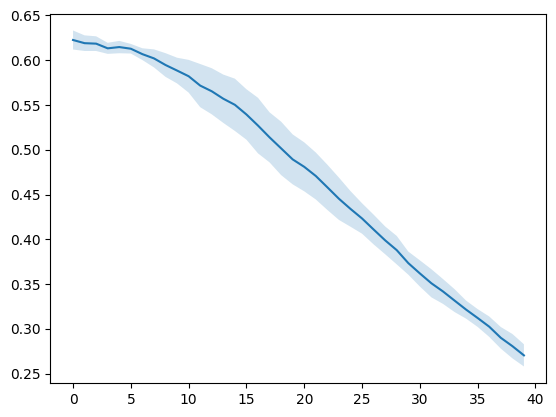

In [31]:
indices = [0,1,3]
acc_meanCategories = np.mean(acc_mean[:,indices], axis=1)
acc_desvCategories = np.std(acc_mean[:,indices], axis=1)
print(acc_meanCategories.shape)
plt.plot(w_delay_values,acc_meanCategories)
plt.fill_between(w_delay_values, acc_meanCategories - acc_desvCategories, acc_meanCategories + acc_desvCategories, alpha=0.2)